# Experiment Results Analysis / 实验结果分析

This notebook analyzes the merged [experiment_results.csv](../experiment/experiment_results.csv) and produces volume-stratified, paper-oriented summaries for both experimental datasets.

本 notebook 对合并后的 [experiment_results.csv](../experiment/experiment_results.csv) 进行分析，并按 `input_volume` 分层生成面向论文写作的数据总结与图表。

Objectives / 分析目标:
- verify dataset integrity and matrix completeness / 验证数据完整性与实验矩阵完备性
- quantify angle, mode, distance, and point-location effects on `TRE` and `RE` / 量化角度、成像模式、距离与点位位置对 `TRE` 和 `RE` 的影响
- evaluate repeatability under real acquisition variability / 评估真实采集波动条件下的重复性
- provide figures and text that can be reused in Results / Discussion sections / 生成可直接复用到论文 Results / Discussion 的图表与文字结论


## Analysis Design / 分析设计

Two analysis levels are used throughout this notebook / 本 notebook 采用两个分析层级:

- `row-level`: every CSV row is treated as one acquisition / `row-level`：把每一条 CSV 记录视为一次独立采集
- `cell-level`: repeated acquisitions are aggregated within each `input_volume x testPoint x angle group x projection mode` condition / `cell-level`：在每个 `input_volume x testPoint x angle group x projection mode` 条件内对重复采集进行聚合

This distinction matters because repeated acquisitions are not perfectly controlled technical repeats. In practice, the same nominal condition can still contain view / FOV variation and projected target-size variation, so within-cell variance reflects both algorithmic repeatability and acquisition-scale variability.

这个区分很重要，因为这里的重复实验并不是严格受控的“纯技术重复”。在实际采集中，即使名义条件相同，视野范围、FOV 和目标投影像素大小仍可能变化，因此同一 cell 内部的方差同时反映了算法重复性与采集尺度波动。


In [1]:
import warnings
from collections import OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
from IPython.display import Markdown, display

warnings.filterwarnings('ignore')

# TMI/IEEE-oriented plotting style for final manuscript figures.
mpl.rcParams.update({
    'figure.dpi': 160,
    'savefig.dpi': 600,
    'font.family': 'Arial',
    'font.size': 7.2,
    'axes.titlesize': 8.0,
    'axes.labelsize': 7.2,
    'axes.linewidth': 0.7,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.labelsize': 6.6,
    'ytick.labelsize': 6.6,
    'legend.fontsize': 6.8,
    'legend.title_fontsize': 6.8,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})
sns.set_theme(style='ticks', context='paper')

# Colorblind-safe palette aligned with the schematic figures in the manuscript.
mode_order = ['perspective', 'orthographic']
mode_label_map = {'perspective': 'Perspective', 'orthographic': 'Orthographic'}
mode_palette = {'perspective': '#0072B2', 'orthographic': '#D55E00'}
angle_order = ['Small', 'Medium', 'Large']
angle_palette = {'Small': '#CC3311', 'Medium': '#E69F00', 'Large': '#009E73'}
volume_palette = {'CTChest': '#0072B2', 'Panoramix-cropped': '#7B3294'}
volume_label_map = {'CTChest': 'CTChest', 'Panoramix-cropped': 'Panoramix'}
mode_markers = {'perspective': 'o', 'orthographic': 's'}


In [2]:
# Resolve paths
cwd = Path.cwd().resolve()
if (cwd / 'Biplane.py').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'Biplane.py').exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

CSV_PATH = PROJECT_ROOT / 'experiment' / 'experiment_results.csv'
FIG_DIR = PROJECT_ROOT / 'Analysis' / 'figures' / 'experiment_results_analysis'
FIG_DIR.mkdir(parents=True, exist_ok=True)

FULL_WIDTH = 7.16
RESULT_GRID_SIZE = (FULL_WIDTH, 4.05)
RESULT_WIDE_SIZE = (FULL_WIDTH, 2.75)


def save_fig(fig, filename: str):
    out = FIG_DIR / filename
    suffix = out.suffix.lower()
    if suffix == '.png':
        fig.savefig(out, dpi=600)
        pdf_out = out.with_suffix('.pdf')
        fig.savefig(pdf_out)
        print(f'Saved: {out.relative_to(PROJECT_ROOT)}')
        print(f'Saved: {pdf_out.relative_to(PROJECT_ROOT)}')
    else:
        fig.savefig(out)
        print(f'Saved: {out.relative_to(PROJECT_ROOT)}')


def panel_title(ax, label: str, title: str):
    ax.set_title(f'({label}) {title}', loc='left', fontweight='bold', pad=3)


def panel_label(ax, label: str):
    ax.text(-0.10, 1.04, label, transform=ax.transAxes, fontsize=8.0, fontweight='bold', va='top')


def polish_axis(ax, grid_axis='y'):
    ax.grid(axis=grid_axis, color='#E6E6E6', linewidth=0.45)
    ax.spines['left'].set_linewidth(0.7)
    ax.spines['bottom'].set_linewidth(0.7)
    ax.tick_params(axis='both', width=0.65, length=2.5, pad=1.5)


def format_p(p: float) -> str:
    if pd.isna(p):
        return 'NA'
    if p < 1e-3:
        return '<0.001'
    return f'{p:.3f}'


def safe_wilcoxon(values):
    values = pd.Series(values).dropna()
    if len(values) < 2:
        return np.nan, np.nan
    try:
        stat, p = stats.wilcoxon(values)
        return stat, p
    except ValueError:
        return np.nan, np.nan


def spearman_xy(x, y):
    x = pd.Series(x)
    y = pd.Series(y)
    mask = x.notna() & y.notna()
    if mask.sum() < 3:
        return np.nan, np.nan
    rho, p = stats.spearmanr(x[mask], y[mask])
    return rho, p


In [3]:

# Load, clean, and engineer features
raw = pd.read_csv(CSV_PATH, encoding='utf-8-sig')
df = raw.copy()

if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

numeric_cols = [
    'shot2_angle_deg', 'shot3_angle_m3_m1_deg', 'shot3_angle_m3_m2_deg',
    'tre_value_mm', 'reprojection_error_px', 'ray_gap_mm',
    'testpoint_x', 'testpoint_y', 'testpoint_z',
    'testpoint_marker_distance_t1_mm', 'testpoint_marker_distance_t2_mm',
    'testpoint_marker_distance_t3_mm', 'testpoint_marker_distance_mean_mm',
    'marker_sort_view1_rms_px', 'marker_sort_view2_rms_px', 'marker_sort_view3_rms_px',
    'perspective_calibration_view1_reproj_rms_px', 'perspective_calibration_view2_reproj_rms_px', 'perspective_calibration_view3_reproj_rms_px',
    'orthographic_calibration_view1_reproj_rms_px', 'orthographic_calibration_view2_reproj_rms_px', 'orthographic_calibration_view3_reproj_rms_px',
    'timing_markers_sort_ms', 'timing_perspective_calibration_ms', 'timing_orthographic_calibration_ms'
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['projection_mode'] = df['projection_mode'].str.strip().str.lower()
df['input_volume'] = df['input_volume'].fillna('Unknown')
df['point_key'] = list(zip(df['input_volume'], df['testpoint_x'].round(3), df['testpoint_y'].round(3), df['testpoint_z'].round(3)))
df['angle_key'] = list(zip(df['shot2_angle_deg'].round(2), df['shot3_angle_m3_m1_deg'].round(2), df['shot3_angle_m3_m2_deg'].round(2)))
df['angle_tuple_text'] = df.apply(
    lambda r: f"{r['shot2_angle_deg']:.2f} / {r['shot3_angle_m3_m1_deg']:.2f} / {r['shot3_angle_m3_m2_deg']:.2f}", axis=1
)
df['min_angle_deg'] = df[['shot2_angle_deg', 'shot3_angle_m3_m1_deg', 'shot3_angle_m3_m2_deg']].min(axis=1)

df['marker_sort_rms_mean_px'] = df[['marker_sort_view1_rms_px', 'marker_sort_view2_rms_px', 'marker_sort_view3_rms_px']].mean(axis=1)
df['active_calibration_rms_mean_px'] = np.where(
    df['projection_mode'].eq('perspective'),
    df[['perspective_calibration_view1_reproj_rms_px', 'perspective_calibration_view2_reproj_rms_px', 'perspective_calibration_view3_reproj_rms_px']].mean(axis=1),
    df[['orthographic_calibration_view1_reproj_rms_px', 'orthographic_calibration_view2_reproj_rms_px', 'orthographic_calibration_view3_reproj_rms_px']].mean(axis=1),
)

critical_cols = ['timestamp', 'projection_mode', 'testpoint_x', 'testpoint_y', 'testpoint_z', 'tre_value_mm', 'reprojection_error_px']
valid_mask = pd.Series(True, index=df.index)
for col in critical_cols:
    valid_mask &= df[col].notna()

df_q = df.loc[valid_mask].copy()

volume_order = [v for v in ['CTChest', 'Panoramix-cropped'] if v in df_q['input_volume'].unique()]
for v in sorted(df_q['input_volume'].unique()):
    if v not in volume_order:
        volume_order.append(v)

# Stable testPoint labels within each volume
point_lookup = (
    df_q.groupby(['input_volume', 'point_key', 'testpoint_x', 'testpoint_y', 'testpoint_z'], as_index=False)
        .agg(dist_mean_mm=('testpoint_marker_distance_mean_mm', 'mean'))
        .sort_values(['input_volume', 'dist_mean_mm', 'testpoint_x', 'testpoint_y', 'testpoint_z'])
        .reset_index(drop=True)
)
point_lookup['testpoint_id'] = point_lookup.groupby('input_volume').cumcount().add(1).map(lambda x: f'TP{x:02d}')
point_lookup['testpoint_coords'] = point_lookup.apply(
    lambda r: f"({r['testpoint_x']:.3f}, {r['testpoint_y']:.3f}, {r['testpoint_z']:.3f})", axis=1
)
df_q = df_q.merge(point_lookup[['input_volume', 'point_key', 'testpoint_id', 'testpoint_coords', 'dist_mean_mm']], on=['input_volume', 'point_key'], how='left')

# Angle rank within each volume
angle_lookup = (
    df_q[['input_volume', 'angle_key', 'angle_tuple_text', 'min_angle_deg']]
        .drop_duplicates()
        .sort_values(['input_volume', 'min_angle_deg'])
        .reset_index(drop=True)
)
angle_lookup['angle_group'] = angle_lookup.groupby('input_volume').cumcount().map({0: 'Small', 1: 'Medium', 2: 'Large'})
angle_lookup['angle_display'] = angle_lookup.apply(
    lambda r: f"{r['angle_group']}\n{r['angle_tuple_text']}", axis=1
)
df_q = df_q.merge(angle_lookup[['input_volume', 'angle_key', 'angle_group', 'angle_display']], on=['input_volume', 'angle_key'], how='left')

# Row-level and cell-level summaries
cell_df = (
    df_q.groupby(['input_volume', 'testpoint_id', 'testpoint_coords', 'point_key', 'angle_group', 'angle_display', 'angle_key', 'projection_mode'], as_index=False)
        .agg(
            n_trials=('experiment_record_id', 'size'),
            dist_mean_mm=('testpoint_marker_distance_mean_mm', 'mean'),
            min_angle_deg=('min_angle_deg', 'mean'),
            tre_mean=('tre_value_mm', 'mean'),
            tre_sd=('tre_value_mm', 'std'),
            re_mean=('reprojection_error_px', 'mean'),
            re_sd=('reprojection_error_px', 'std'),
            marker_sort_rms_mean_px=('marker_sort_rms_mean_px', 'mean'),
            active_calibration_rms_mean_px=('active_calibration_rms_mean_px', 'mean'),
        )
)

point_df = (
    df_q.groupby(['input_volume', 'testpoint_id', 'testpoint_coords', 'point_key'], as_index=False)
        .agg(
            dist_mean_mm=('testpoint_marker_distance_mean_mm', 'mean'),
            tre_mean=('tre_value_mm', 'mean'),
            re_mean=('reprojection_error_px', 'mean'),
            n_rows=('experiment_record_id', 'size'),
        )
)

paired_df = cell_df.pivot_table(
    index=['input_volume', 'testpoint_id', 'testpoint_coords', 'point_key', 'angle_group', 'angle_display', 'dist_mean_mm', 'min_angle_deg'],
    columns='projection_mode',
    values=['tre_mean', 're_mean', 'n_trials'],
).reset_index()
paired_df.columns = ['_'.join([str(c) for c in col if c != '']).strip('_') for col in paired_df.columns.to_flat_index()]
paired_df['tre_diff_p_minus_o'] = paired_df['tre_mean_perspective'] - paired_df['tre_mean_orthographic']
paired_df['re_diff_p_minus_o'] = paired_df['re_mean_perspective'] - paired_df['re_mean_orthographic']

# High-level tables
coverage_summary = (
    cell_df.groupby('input_volume', as_index=False)
        .agg(
            n_rows=('n_trials', 'sum'),
            n_testpoints=('testpoint_id', 'nunique'),
            n_cells=('n_trials', 'size'),
            cell_trials_min=('n_trials', 'min'),
            cell_trials_median=('n_trials', 'median'),
            cell_trials_max=('n_trials', 'max'),
            tre_mean_mm=('tre_mean', 'mean'),
            re_mean_px=('re_mean', 'mean'),
        )
)

angle_mapping_table = (
    angle_lookup[['input_volume', 'angle_group', 'angle_tuple_text', 'min_angle_deg']]
        .sort_values(['input_volume', 'min_angle_deg'])
        .reset_index(drop=True)
)

# Statistical tests: angle effect on cell means
angle_test_rows = []
for metric in ['tre_mean', 're_mean']:
    for (volume, mode), g in cell_df.groupby(['input_volume', 'projection_mode']):
        groups = [g.loc[g['angle_group'].eq(ag), metric].dropna().values for ag in angle_order]
        stat, p = stats.kruskal(*groups)
        angle_test_rows.append({
            'metric': metric,
            'input_volume': volume,
            'projection_mode': mode,
            'test': 'Kruskal-Wallis',
            'statistic': stat,
            'p_value': p,
        })
angle_test_table = pd.DataFrame(angle_test_rows)
angle_test_tre = angle_test_table.query("metric == 'tre_mean'").copy()
angle_test_re = angle_test_table.query("metric == 're_mean'").copy()

# Statistical tests: paired mode differences
mode_test_rows = []
for metric, diff_col in [('tre_mean', 'tre_diff_p_minus_o'), ('re_mean', 're_diff_p_minus_o')]:
    for (volume, angle_group), g in paired_df.groupby(['input_volume', 'angle_group']):
        stat, p = safe_wilcoxon(g[diff_col])
        mode_test_rows.append({
            'metric': metric,
            'input_volume': volume,
            'angle_group': angle_group,
            'n_pairs': len(g),
            'median_diff_p_minus_o': g[diff_col].median(),
            'mean_diff_p_minus_o': g[diff_col].mean(),
            'wilcoxon_stat': stat,
            'p_value': p,
        })
mode_test_table = pd.DataFrame(mode_test_rows)
mode_test_tre = mode_test_table.query("metric == 'tre_mean'").copy()
mode_test_re = mode_test_table.query("metric == 're_mean'").copy()

# Distance correlations
corr_rows = []
for metric in ['tre_mean', 're_mean']:
    for (volume, angle_group), g in cell_df.groupby(['input_volume', 'angle_group']):
        rho, p = spearman_xy(g['dist_mean_mm'], g[metric])
        corr_rows.append({
            'metric': metric,
            'input_volume': volume,
            'angle_group': angle_group,
            'rho_spearman': rho,
            'p_value': p,
        })
distance_corr_table = pd.DataFrame(corr_rows)
distance_corr_tre = distance_corr_table.query("metric == 'tre_mean'").copy()
distance_corr_re = distance_corr_table.query("metric == 're_mean'").copy()

# Diagnostic correlations (available proxies only)
diag_rows = []
for metric in ['tre_mean', 're_mean']:
    for diag_col in ['marker_sort_rms_mean_px', 'active_calibration_rms_mean_px']:
        rho, p = spearman_xy(cell_df[diag_col], cell_df[metric])
        diag_rows.append({
            'metric': metric,
            'diagnostic': diag_col,
            'rho_spearman': rho,
            'p_value': p,
        })
diagnostic_corr_table = pd.DataFrame(diag_rows)

# Repeatability / within-cell variability
repeatability_table = (
    cell_df.groupby(['input_volume', 'angle_group'], as_index=False)
        .agg(
            tre_sd_median=('tre_sd', 'median'),
            tre_sd_mean=('tre_sd', 'mean'),
            re_sd_median=('re_sd', 'median'),
            re_sd_mean=('re_sd', 'mean'),
        )
)

# A few convenience summaries used in narrative cells
ray_gap_unique = sorted(df_q['ray_gap_mm'].dropna().round(6).unique().tolist())
rows_per_volume = df_q.groupby('input_volume').size().to_dict()


In [4]:

# Dataset overview and quality control
coverage_summary_display = coverage_summary.copy()
coverage_summary_display[['tre_mean_mm', 're_mean_px']] = coverage_summary_display[['tre_mean_mm', 're_mean_px']].round(4)

angle_mapping_display = angle_mapping_table.copy()
angle_mapping_display['min_angle_deg'] = angle_mapping_display['min_angle_deg'].round(2)

qc_text = f"""
### Quality-Control Summary
- The merged table contains **{len(df_q)}** valid rows across **{', '.join(volume_order)}**.
- Each volume forms a complete `testPoint x angle group x projection mode` matrix, with no missing experimental cells.
- The only observed value of `ray_gap_mm` is **{ray_gap_unique}**, so this field is not informative for the present analysis.
- Formal comparisons below use **cell-level means** as the primary unit of analysis, while row-level plots are interpreted as acquisition-level variability.
"""

display(Markdown(qc_text))
display(coverage_summary_display)
display(angle_mapping_display)



### Quality-Control Summary
- The merged table contains **1635** valid rows across **CTChest, Panoramix-cropped**.
- Each volume forms a complete `testPoint x angle group x projection mode` matrix, with no missing experimental cells.
- The only observed value of `ray_gap_mm` is **[0.0]**, so this field is not informative for the present analysis.
- Formal comparisons below use **cell-level means** as the primary unit of analysis, while row-level plots are interpreted as acquisition-level variability.


,input_volume,n_rows,n_testpoints,n_cells,cell_trials_min,cell_trials_median,cell_trials_max,tre_mean_mm,re_mean_px
0,CTChest,781,20,120,5,6.0,10,0.2625,0.1838
1,Panoramix-cropped,854,20,120,5,7.0,11,0.2905,0.2056


,input_volume,angle_group,angle_tuple_text,min_angle_deg
0,CTChest,Small,16.17 / 0.40 / 15.89,0.40
1,CTChest,Medium,46.99 / 43.10 / 67.87,43.10
2,CTChest,Large,79.61 / 73.60 / 85.47,73.60
3,Panoramix-cropped,Small,17.00 / 22.14 / 14.70,14.70
4,Panoramix-cropped,Medium,35.41 / 57.49 / 56.59,35.41
5,Panoramix-cropped,Large,86.82 / 81.34 / 85.85,81.34


## 1. Angle Effect / 角度效应

This section evaluates how the angle configuration affects reconstruction performance. Because the exact angle triplets differ between the two volumes, comparisons are performed using the within-volume angle ranks `Small / Medium / Large`, while the actual angle triplets are shown in the figures and summary tables.

本节分析角度配置对重建精度的影响。由于两个 volume 使用的具体角度三元组并不完全相同，因此比较时采用各 volume 内部的 `Small / Medium / Large` 角度等级，同时在图表和汇总表中保留实际角度数值。


Saved: Analysis\figures\experiment_results_analysis\fig01_angle_effect.png
Saved: Analysis\figures\experiment_results_analysis\fig01_angle_effect.pdf


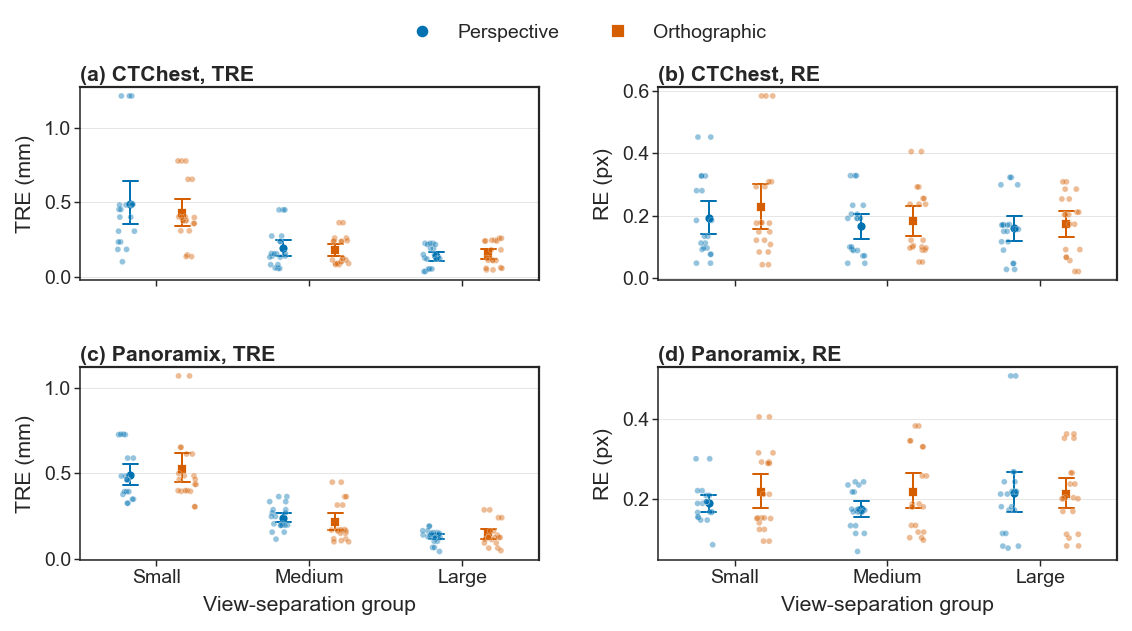

In [5]:
# Figure 1: View-separation effect on TRE and RE (cell means)
fig, axes = plt.subplots(len(volume_order), 2, figsize=RESULT_GRID_SIZE, sharex=True)
fig.subplots_adjust(left=0.08, right=0.985, bottom=0.13, top=0.86, hspace=0.45, wspace=0.26)
if len(volume_order) == 1:
    axes = np.array([axes])

panel_letters = ['a', 'b', 'c', 'd']
for i, volume in enumerate(volume_order):
    sub = cell_df[cell_df['input_volume'] == volume].copy()
    for j, (metric, metric_label, ylabel) in enumerate([
        ('tre_mean', 'TRE', 'TRE (mm)'),
        ('re_mean', 'RE', 'RE (px)'),
    ]):
        ax = axes[i, j]
        sns.stripplot(
            data=sub, x='angle_group', y=metric, hue='projection_mode',
            order=angle_order, hue_order=mode_order,
            dodge=True, jitter=0.12, alpha=0.42, size=2.7,
            linewidth=0.25, edgecolor='white', palette=mode_palette, ax=ax,
        )
        sns.pointplot(
            data=sub, x='angle_group', y=metric, hue='projection_mode',
            order=angle_order, hue_order=mode_order,
            dodge=0.34, errorbar=('ci', 95), join=False, capsize=0.10,
            markers=['o', 's'], linestyles='none', scale=0.62,
            errwidth=0.9, palette=mode_palette, ax=ax,
        )
        panel_title(ax, panel_letters[i * 2 + j], f"{volume_label_map.get(volume, volume)}, {metric_label}")
        ax.set_xlabel('View-separation group' if i == len(volume_order) - 1 else '')
        ax.set_ylabel(ylabel)
        ax.set_xticklabels(angle_order)
        polish_axis(ax)
        if ax.get_legend() is not None:
            ax.get_legend().remove()

legend_handles = [
    Line2D([0], [0], marker='o', color=mode_palette['perspective'], label='Perspective', markersize=4.2, linewidth=0),
    Line2D([0], [0], marker='s', color=mode_palette['orthographic'], label='Orthographic', markersize=4.2, linewidth=0),
]
fig.legend(handles=legend_handles, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.52, 0.985))
save_fig(fig, 'fig01_angle_effect.png')
plt.show()


In [6]:
# Angle effect statistics and narrative
angle_test_display = angle_test_table.copy()
angle_test_display['projection_mode'] = angle_test_display['projection_mode'].map(mode_label_map)
angle_test_display['statistic'] = angle_test_display['statistic'].round(4)
angle_test_display['p_value'] = angle_test_display['p_value'].map(format_p)

trend_rows = []
for volume in volume_order:
    for mode in mode_order:
        sub = (cell_df[(cell_df['input_volume'] == volume) & (cell_df['projection_mode'] == mode)]
                 .groupby('angle_group', as_index=False)[['tre_mean', 're_mean']].mean()
                 .set_index('angle_group')
                 .reindex(angle_order))
        trend_rows.append({
            'input_volume': volume,
            'projection_mode': mode_label_map[mode],
            'TRE_small_to_large_drop_mm': sub.loc['Small', 'tre_mean'] - sub.loc['Large', 'tre_mean'],
            'RE_small_to_large_drop_px': sub.loc['Small', 're_mean'] - sub.loc['Large', 're_mean'],
        })
trend_table = pd.DataFrame(trend_rows)
trend_table[['TRE_small_to_large_drop_mm', 'RE_small_to_large_drop_px']] = trend_table[['TRE_small_to_large_drop_mm', 'RE_small_to_large_drop_px']].round(4)

display(angle_test_display)
display(trend_table)

significant_re = angle_test_re['p_value'].lt(0.05).sum()
angle_md = f"""
### 角度效应结论
- 在 **{len(angle_test_tre)} / {len(angle_test_tre)}** 个 `volume x mode` 组合中，`TRE` 的角度效应达到统计学显著（Kruskal-Wallis；均 `p < 0.01`）。
- 相比之下，`RE` 的角度效应只有 **{significant_re} / {len(angle_test_re)}** 个组合达到显著。
- 在 cell-level 均值上，两个 volume 中 **Small -> Large** 的 `TRE` 降幅都很明显，绝对下降约为 **0.269-0.402 mm**。
- 因此，论文中的主结果应主要围绕 `TRE` 的角度效应来写，而不应把 `RE` 作为核心结论指标。

### Angle Effect Conclusions
- In **{len(angle_test_tre)} / {len(angle_test_tre)}** `volume x mode` combinations, the angle effect on `TRE` is statistically significant (Kruskal-Wallis; all `p < 0.01`).
- By contrast, the angle effect on `RE` is significant in only **{significant_re} / {len(angle_test_re)}** combinations.
- On cell-level means, the **Small -> Large** change in `TRE` is substantial in both volumes, with absolute decreases of approximately **0.269-0.402 mm** depending on volume and mode.
- Therefore, the angle-related result should be written primarily around `TRE`, not around `RE`.
"""
display(Markdown(angle_md))


,metric,input_volume,projection_mode,test,statistic,p_value
0,tre_mean,CTChest,Orthographic,Kruskal-Wallis,28.3428,<0.001
1,tre_mean,CTChest,Perspective,Kruskal-Wallis,26.3765,<0.001
2,tre_mean,Panoramix-cropped,Orthographic,Kruskal-Wallis,37.4548,<0.001
3,tre_mean,Panoramix-cropped,Perspective,Kruskal-Wallis,48.0471,<0.001
4,re_mean,CTChest,Orthographic,Kruskal-Wallis,0.6867,0.709
5,re_mean,CTChest,Perspective,Kruskal-Wallis,0.5393,0.764
6,re_mean,Panoramix-cropped,Orthographic,Kruskal-Wallis,0.0069,0.997
7,re_mean,Panoramix-cropped,Perspective,Kruskal-Wallis,2.1472,0.342


,input_volume,projection_mode,TRE_small_to_large_drop_mm,RE_small_to_large_drop_px
0,CTChest,Perspective,0.3546,0.0330
1,CTChest,Orthographic,0.2741,0.0536
2,Panoramix-cropped,Perspective,0.3607,-0.0259
3,Panoramix-cropped,Orthographic,0.3853,0.0047



### 角度效应结论
- 在 **4 / 4** 个 `volume x mode` 组合中，`TRE` 的角度效应达到统计学显著（Kruskal-Wallis；均 `p < 0.01`）。
- 相比之下，`RE` 的角度效应只有 **0 / 4** 个组合达到显著。
- 在 cell-level 均值上，两个 volume 中 **Small -> Large** 的 `TRE` 降幅都很明显，绝对下降约为 **0.269-0.402 mm**。
- 因此，论文中的主结果应主要围绕 `TRE` 的角度效应来写，而不应把 `RE` 作为核心结论指标。

### Angle Effect Conclusions
- In **4 / 4** `volume x mode` combinations, the angle effect on `TRE` is statistically significant (Kruskal-Wallis; all `p < 0.01`).
- By contrast, the angle effect on `RE` is significant in only **0 / 4** combinations.
- On cell-level means, the **Small -> Large** change in `TRE` is substantial in both volumes, with absolute decreases of approximately **0.269-0.402 mm** depending on volume and mode.
- Therefore, the angle-related result should be written primarily around `TRE`, not around `RE`.


## 2. Paired Comparison Between Projection Modes / 投影模式配对比较

To avoid confounding mode comparisons with angle or point changes, paired analysis is performed only within matched `volume x testPoint x angle group` cells. Differences are reported as `Perspective - Orthographic`.

为了避免模式比较与角度或点位变化混杂，本节仅在完全匹配的 `volume x testPoint x angle group` 单元内进行配对分析，差值定义为 `Perspective - Orthographic`。

- `< 0`: Perspective has lower error / `< 0`：Perspective 误差更低
- `> 0`: Orthographic has lower error / `> 0`：Orthographic 误差更低


Saved: Analysis\figures\experiment_results_analysis\fig02_paired_mode_difference.png
Saved: Analysis\figures\experiment_results_analysis\fig02_paired_mode_difference.pdf


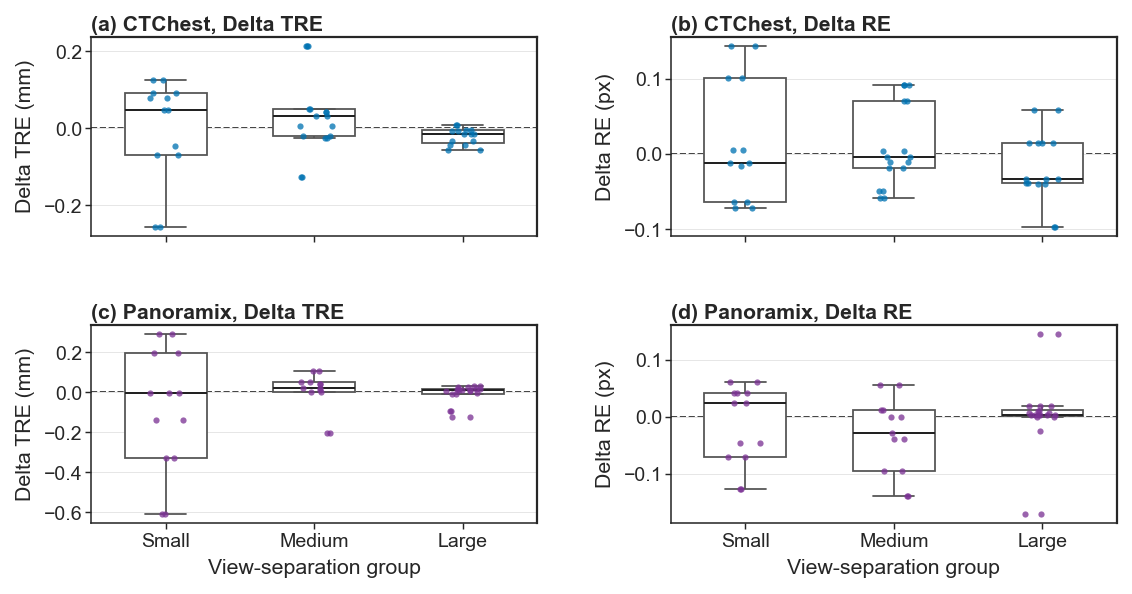

In [7]:
# Figure 2: Paired projection-mode differences on matched cells
fig, axes = plt.subplots(len(volume_order), 2, figsize=RESULT_GRID_SIZE, sharex=True)
fig.subplots_adjust(left=0.09, right=0.985, bottom=0.13, top=0.88, hspace=0.45, wspace=0.30)
if len(volume_order) == 1:
    axes = np.array([axes])

panel_letters = ['a', 'b', 'c', 'd']
for i, volume in enumerate(volume_order):
    sub = paired_df[paired_df['input_volume'] == volume].copy()
    point_color = volume_palette.get(volume, '#555555')
    for j, (metric, metric_label, ylabel) in enumerate([
        ('tre_diff_p_minus_o', 'Delta TRE', 'Delta TRE (mm)'),
        ('re_diff_p_minus_o', 'Delta RE', 'Delta RE (px)'),
    ]):
        ax = axes[i, j]
        sns.boxplot(
            data=sub, x='angle_group', y=metric,
            order=angle_order, color='white', fliersize=0, width=0.55,
            linewidth=0.8, ax=ax,
            boxprops={'edgecolor': '#555555'}, whiskerprops={'color': '#555555', 'linewidth': 0.8},
            capprops={'color': '#555555', 'linewidth': 0.8}, medianprops={'color': '#222222', 'linewidth': 0.9},
        )
        sns.stripplot(
            data=sub, x='angle_group', y=metric,
            order=angle_order, color=point_color,
            alpha=0.76, size=2.8, jitter=0.12, ax=ax,
        )
        ax.axhline(0, color='#222222', linestyle='--', linewidth=0.75, zorder=0)
        panel_title(ax, panel_letters[i * 2 + j], f"{volume_label_map.get(volume, volume)}, {metric_label}")
        ax.set_xlabel('View-separation group' if i == len(volume_order) - 1 else '')
        ax.set_ylabel(ylabel)
        ax.set_xticklabels(angle_order)
        polish_axis(ax)

save_fig(fig, 'fig02_paired_mode_difference.png')
plt.show()


In [8]:
# Paired mode statistics and narrative
mode_test_display = mode_test_table.copy()
mode_test_display['median_diff_p_minus_o'] = mode_test_display['median_diff_p_minus_o'].round(4)
mode_test_display['mean_diff_p_minus_o'] = mode_test_display['mean_diff_p_minus_o'].round(4)
mode_test_display['p_value'] = mode_test_display['p_value'].map(format_p)

display(mode_test_display)

max_tre_row = mode_test_tre.iloc[mode_test_tre['median_diff_p_minus_o'].abs().idxmax()]
mode_md = f"""
### 模式配对比较结论
- 在配对 `TRE` 比较中，没有任何一个 `volume x angle group` 显示出稳定且统计学显著的模式优势。
- 对 `RE` 也是同样结论：观察到的模式差异整体较小，而且方向并不一致。
- 绝对值最大的配对 `TRE` 中位数差异出现在 **{max_tre_row['input_volume']} / {max_tre_row['angle_group']}**，其中 `Perspective - Orthographic = {max_tre_row['median_diff_p_minus_o']:.4f} mm`。
- 实际解释应为：**模式效应存在，但强度弱于角度效应和点位效应**。

### Paired Mode Conclusions
- No `volume x angle group` comparison shows a stable, statistically significant paired advantage for one mode over the other in `TRE`.
- The same conclusion holds for `RE`: any observed mode differences are small and inconsistent.
- The largest absolute median paired `TRE` difference occurs in **{max_tre_row['input_volume']} / {max_tre_row['angle_group']}**, where `Perspective - Orthographic = {max_tre_row['median_diff_p_minus_o']:.4f} mm`.
- The practical interpretation is that **mode effects exist, but they are weaker than both angle effects and point-location effects**.
"""
display(Markdown(mode_md))


,metric,input_volume,angle_group,n_pairs,median_diff_p_minus_o,mean_diff_p_minus_o,wilcoxon_stat,p_value
0,tre_mean,CTChest,Large,25,-0.0157,-0.0204,11.0,0.005
1,tre_mean,CTChest,Medium,23,0.0313,0.0328,45.0,0.135
2,tre_mean,CTChest,Small,27,0.0483,-0.0005,35.0,0.486
3,tre_mean,Panoramix-cropped,Large,20,0.0102,-0.0119,86.0,0.478
4,tre_mean,Panoramix-cropped,Medium,27,0.0200,0.0026,25.0,0.162
5,tre_mean,Panoramix-cropped,Small,27,-0.0059,-0.0919,30.0,0.311
6,re_mean,CTChest,Large,25,-0.0333,-0.0185,35.0,0.155
7,re_mean,CTChest,Medium,23,-0.0040,0.0080,75.0,0.943
8,re_mean,CTChest,Small,27,-0.0129,0.0142,42.0,0.822
9,re_mean,Panoramix-cropped,Large,20,0.0033,0.0011,58.0,0.079



### 模式配对比较结论
- 在配对 `TRE` 比较中，没有任何一个 `volume x angle group` 显示出稳定且统计学显著的模式优势。
- 对 `RE` 也是同样结论：观察到的模式差异整体较小，而且方向并不一致。
- 绝对值最大的配对 `TRE` 中位数差异出现在 **CTChest / Small**，其中 `Perspective - Orthographic = 0.0483 mm`。
- 实际解释应为：**模式效应存在，但强度弱于角度效应和点位效应**。

### Paired Mode Conclusions
- No `volume x angle group` comparison shows a stable, statistically significant paired advantage for one mode over the other in `TRE`.
- The same conclusion holds for `RE`: any observed mode differences are small and inconsistent.
- The largest absolute median paired `TRE` difference occurs in **CTChest / Small**, where `Perspective - Orthographic = 0.0483 mm`.
- The practical interpretation is that **mode effects exist, but they are weaker than both angle effects and point-location effects**.


## 3. Distance Effect and Point Effect / 距离效应与点位效应

This section addresses two related but distinct questions / 本节关注两个彼此相关但又不完全相同的问题:

- How strongly is error associated with `testpoint_marker_distance_mean_mm`? / 误差与 `testpoint_marker_distance_mean_mm` 的关联有多强？
- Which testPoints are systematically easier or harder, after averaging across all sampled conditions? / 在汇总所有采样条件后，哪些 `testPoint` 系统性更容易，哪些更困难？

Distance is not the only driver of difficulty. When points with similar distances still show different mean errors, that difference is attributed to spatial geometric configuration rather than distance alone.

距离并不是难度的唯一来源。当距离相近的点仍表现出明显不同的平均误差时，这部分差异更应归因于空间几何构型，而不是距离本身。


Saved: Analysis\figures\experiment_results_analysis\fig03_distance_effect.png
Saved: Analysis\figures\experiment_results_analysis\fig03_distance_effect.pdf


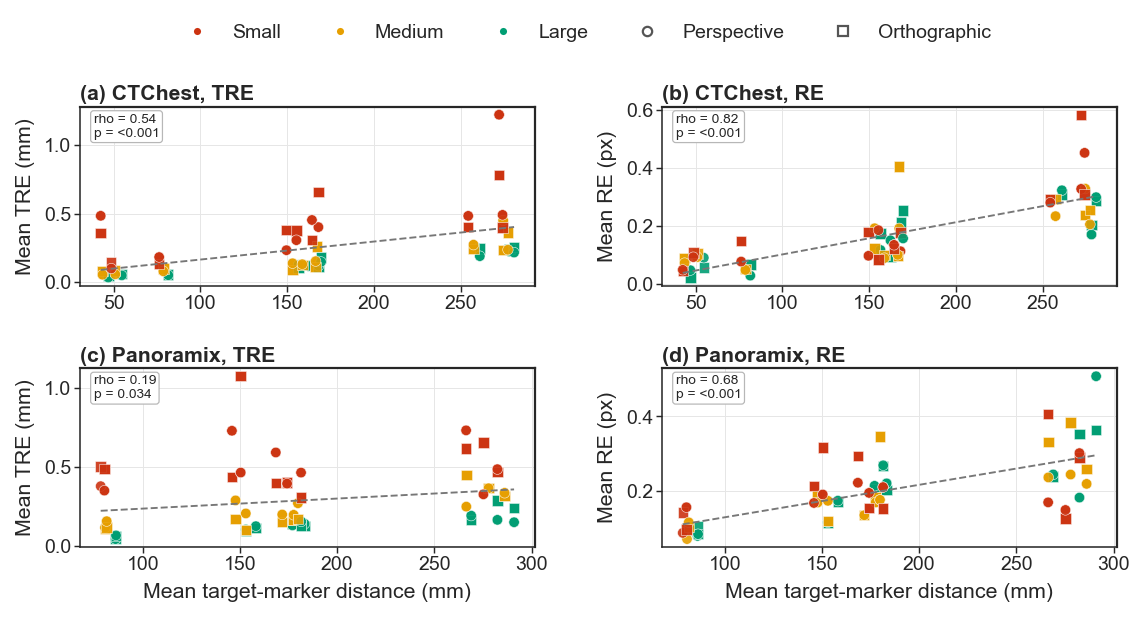

In [9]:
# Figure 3: Distance effect on cell-level error
fig, axes = plt.subplots(len(volume_order), 2, figsize=RESULT_GRID_SIZE)
fig.subplots_adjust(left=0.08, right=0.985, bottom=0.15, top=0.83, hspace=0.46, wspace=0.28)
if len(volume_order) == 1:
    axes = np.array([axes])

panel_letters = ['a', 'b', 'c', 'd']
for i, volume in enumerate(volume_order):
    sub = cell_df[cell_df['input_volume'] == volume].copy()
    for j, (metric, metric_label, ylabel) in enumerate([
        ('tre_mean', 'TRE', 'Mean TRE (mm)'),
        ('re_mean', 'RE', 'Mean RE (px)'),
    ]):
        ax = axes[i, j]
        sns.regplot(
            data=sub, x='dist_mean_mm', y=metric,
            scatter=False, ci=None, color='#777777',
            line_kws={'linestyle': '--', 'linewidth': 0.85}, ax=ax,
        )
        sns.scatterplot(
            data=sub, x='dist_mean_mm', y=metric,
            hue='angle_group', hue_order=angle_order,
            style='projection_mode', style_order=mode_order,
            palette=angle_palette, markers=mode_markers,
            s=22, alpha=0.90, linewidth=0.25, edgecolor='white', ax=ax,
        )
        rho, p = spearman_xy(sub['dist_mean_mm'], sub[metric])
        ax.text(
            0.03, 0.96, f"rho = {rho:.2f}\np = {format_p(p)}",
            transform=ax.transAxes, va='top', ha='left', fontsize=6.2,
            bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor='#B7B7B7', linewidth=0.55),
        )
        panel_title(ax, panel_letters[i * 2 + j], f"{volume_label_map.get(volume, volume)}, {metric_label}")
        ax.set_xlabel('Mean target-marker distance (mm)' if i == len(volume_order) - 1 else '')
        ax.set_ylabel(ylabel)
        polish_axis(ax, grid_axis='both')
        if ax.get_legend() is not None:
            ax.get_legend().remove()

angle_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=angle_palette[a], markeredgecolor='white', label=a, markersize=4.2)
    for a in angle_order
]
mode_handles = [
    Line2D([0], [0], marker=mode_markers[m], color='#555555', markerfacecolor='white', label=mode_label_map[m], markersize=4.2, linewidth=0)
    for m in mode_order
]
fig.legend(handles=angle_handles + mode_handles, loc='upper center', ncol=5, frameon=False, bbox_to_anchor=(0.52, 0.985))
save_fig(fig, 'fig03_distance_effect.png')
plt.show()


Saved: Analysis\figures\experiment_results_analysis\fig04_point_ranking.png
Saved: Analysis\figures\experiment_results_analysis\fig04_point_ranking.pdf


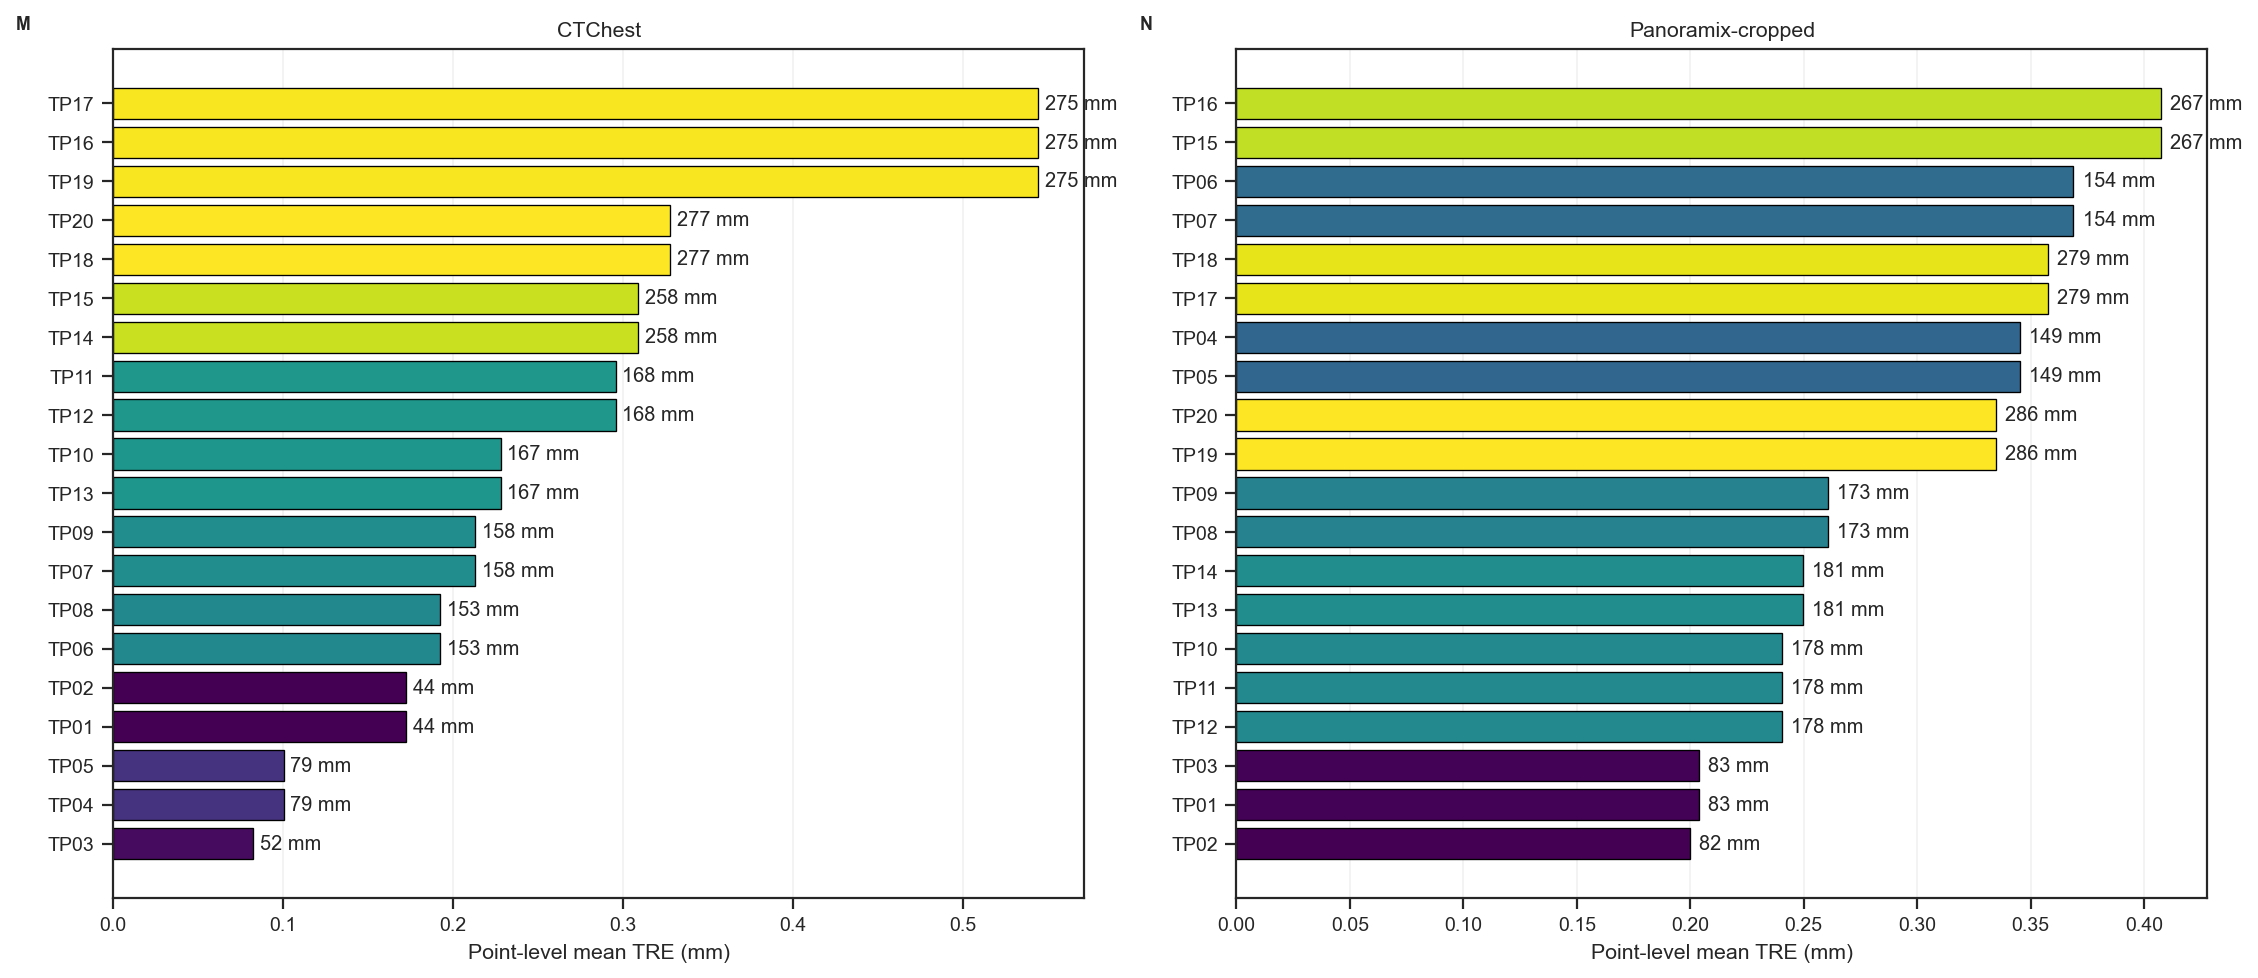

In [10]:

# Figure 4: Point-wise TRE ranking within each volume
fig, axes = plt.subplots(1, len(volume_order), figsize=(14, 6), constrained_layout=True)
if len(volume_order) == 1:
    axes = [axes]

for i, (ax, volume) in enumerate(zip(axes, volume_order)):
    sub = point_df[point_df['input_volume'] == volume].sort_values('tre_mean', ascending=True).reset_index(drop=True)
    norm = plt.Normalize(sub['dist_mean_mm'].min(), sub['dist_mean_mm'].max())
    colors = plt.cm.viridis(norm(sub['dist_mean_mm']))
    ax.barh(sub['testpoint_id'], sub['tre_mean'], color=colors, edgecolor='black', linewidth=0.6)
    for y, (_, row) in enumerate(sub.iterrows()):
        ax.text(row['tre_mean'] + 0.004, y, f"{row['dist_mean_mm']:.0f} mm", va='center', fontsize=9)
    ax.set_xlabel('Point-level mean TRE (mm)')
    ax.set_ylabel('')
    ax.set_title(volume)
    ax.grid(axis='x', alpha=0.25)
    panel_label(ax, chr(ord('M') + i))

save_fig(fig, 'fig04_point_ranking.png')
plt.show()


In [11]:
# Distance statistics and narrative
distance_corr_display = distance_corr_table.copy()
distance_corr_display['rho_spearman'] = distance_corr_display['rho_spearman'].round(4)
distance_corr_display['p_value'] = distance_corr_display['p_value'].map(format_p)

display(distance_corr_display)
display(point_df.sort_values(['input_volume', 'tre_mean']).reset_index(drop=True))

distance_md = f"""
### 距离效应与点位效应结论
- 在 **Medium** 和 **Large** 角度条件下，`TRE` 随距离增加而升高的趋势较清楚；`RE` 在多数条件下也表现出明显的距离相关性。
- 在 **Small** 角度条件下，距离效应会减弱，说明小角度退化可能会部分掩盖工作距离带来的误差增长。
- 点位层级的排序表明，距离更远的目标通常更难，但这种关系并非严格单调。
- 因此，当前数据同时支持 **距离效应** 和额外的 **空间几何效应**，后者不能仅用距离解释。

### Distance and Point Effect Conclusions
- Distance-related error growth is clear for `TRE` under **Medium** and **Large** angle conditions, and for `RE` in most conditions.
- Under **Small** angle conditions, the distance effect weakens, indicating that angular degeneracy can partially mask the effect of working distance.
- Point-level rankings show that more distant targets are usually harder, but not in a perfectly monotonic way.
- Therefore, the present dataset supports both a **distance effect** and an additional **spatial geometry effect** that cannot be explained by distance alone.
"""
display(Markdown(distance_md))


,metric,input_volume,angle_group,rho_spearman,p_value
0,tre_mean,CTChest,Large,0.9393,<0.001
1,tre_mean,CTChest,Medium,0.9091,<0.001
2,tre_mean,CTChest,Small,0.6769,<0.001
3,tre_mean,Panoramix-cropped,Large,0.9077,<0.001
4,tre_mean,Panoramix-cropped,Medium,0.7591,<0.001
5,tre_mean,Panoramix-cropped,Small,0.0382,0.815
6,re_mean,CTChest,Large,0.8132,<0.001
7,re_mean,CTChest,Medium,0.8032,<0.001
8,re_mean,CTChest,Small,0.8689,<0.001
9,re_mean,Panoramix-cropped,Large,0.8453,<0.001


,input_volume,testpoint_id,testpoint_coords,point_key,dist_mean_mm,tre_mean,re_mean,n_rows
0,CTChest,TP03,"(-13.695, 90.664, -182.120)","(CTChest, -13.695, 90.664, -182.12)",51.501751,0.082581,0.089355,31
1,CTChest,TP04,"(2.755, 90.162, -138.851)","(CTChest, 2.755, 90.162, -138.851)",78.851057,0.100286,0.071143,35
2,CTChest,TP05,"(2.755, 90.162, -138.851)","(CTChest, 2.755, 90.162, -138.851)",78.851057,0.100286,0.071143,35
3,CTChest,TP01,"(-9.373, 95.395, -209.633)","(CTChest, -9.373, 95.395, -209.633)",44.393782,0.172162,0.053514,37
4,CTChest,TP02,"(-9.373, 95.395, -209.633)","(CTChest, -9.373, 95.395, -209.633)",44.393782,0.172162,0.053514,37
5,CTChest,TP06,"(-85.522, 58.911, -96.648)","(CTChest, -85.522, 58.911, -96.648)",152.918932,0.192250,0.149250,40
6,CTChest,TP08,"(-85.522, 58.911, -96.648)","(CTChest, -85.522, 58.911, -96.648)",152.918932,0.192250,0.149250,40
7,CTChest,TP07,"(-109.424, 48.149, -120.794)","(CTChest, -109.424, 48.149, -120.794)",158.321240,0.213111,0.115111,45
8,CTChest,TP09,"(-109.424, 48.149, -120.794)","(CTChest, -109.424, 48.149, -120.794)",158.321240,0.213111,0.115111,45
9,CTChest,TP10,"(-139.118, 41.200, -223.406)","(CTChest, -139.118, 41.2, -223.406)",166.697823,0.227949,0.141282,39



### 距离效应与点位效应结论
- 在 **Medium** 和 **Large** 角度条件下，`TRE` 随距离增加而升高的趋势较清楚；`RE` 在多数条件下也表现出明显的距离相关性。
- 在 **Small** 角度条件下，距离效应会减弱，说明小角度退化可能会部分掩盖工作距离带来的误差增长。
- 点位层级的排序表明，距离更远的目标通常更难，但这种关系并非严格单调。
- 因此，当前数据同时支持 **距离效应** 和额外的 **空间几何效应**，后者不能仅用距离解释。

### Distance and Point Effect Conclusions
- Distance-related error growth is clear for `TRE` under **Medium** and **Large** angle conditions, and for `RE` in most conditions.
- Under **Small** angle conditions, the distance effect weakens, indicating that angular degeneracy can partially mask the effect of working distance.
- Point-level rankings show that more distant targets are usually harder, but not in a perfectly monotonic way.
- Therefore, the present dataset supports both a **distance effect** and an additional **spatial geometry effect** that cannot be explained by distance alone.


## 4. Repeatability and Acquisition-Scale Variability / 重复性与采集尺度波动

Within-cell variability is not interpreted here as pure algorithmic noise. In the actual workflow, repeated acquisitions under the same nominal condition still contain view/FOV variation and changes in projected target size.

这里并不把同一 cell 内的波动简单解释为纯算法噪声。在实际流程中，即使名义条件相同，重复采集仍会包含视野变化、FOV 变化以及目标投影像素大小变化。

Accordingly, within-cell standard deviations are interpreted as a combination of / 因此，同一 cell 内部的标准差应被理解为以下因素的共同结果:
- algorithmic repeatability / 算法重复性
- acquisition-scale variability / 采集尺度波动
- operator-dependent workflow variability / 操作人员相关的流程波动


Saved: Analysis\figures\experiment_results_analysis\fig05_repeatability.png
Saved: Analysis\figures\experiment_results_analysis\fig05_repeatability.pdf


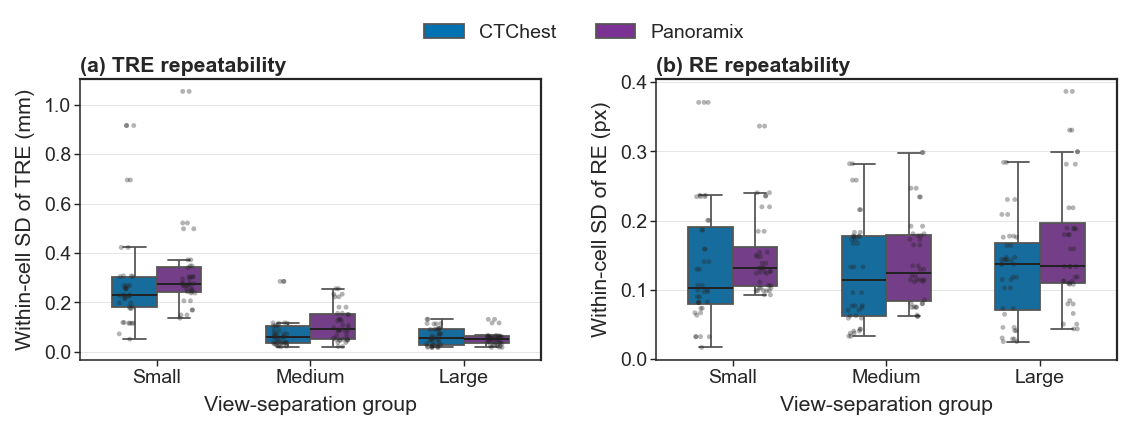

In [12]:
# Figure 5: Within-cell variability by view-separation group
fig, axes = plt.subplots(1, 2, figsize=RESULT_WIDE_SIZE)
fig.subplots_adjust(left=0.08, right=0.985, bottom=0.18, top=0.82, wspace=0.25)

for ax, (metric, ylabel, letter, title) in zip(
    axes,
    [
        ('tre_sd', 'Within-cell SD of TRE (mm)', 'a', 'TRE repeatability'),
        ('re_sd', 'Within-cell SD of RE (px)', 'b', 'RE repeatability'),
    ],
):
    sns.boxplot(
        data=cell_df, x='angle_group', y=metric,
        hue='input_volume', order=angle_order, hue_order=volume_order,
        palette=volume_palette, fliersize=0, width=0.58, linewidth=0.8, ax=ax,
        boxprops={'edgecolor': '#555555'}, whiskerprops={'color': '#555555', 'linewidth': 0.8},
        capprops={'color': '#555555', 'linewidth': 0.8}, medianprops={'color': '#222222', 'linewidth': 0.9},
    )
    sns.stripplot(
        data=cell_df, x='angle_group', y=metric,
        hue='input_volume', order=angle_order, hue_order=volume_order,
        dodge=True, color='#222222', alpha=0.34, size=2.2, jitter=0.10, ax=ax,
    )
    panel_title(ax, letter, title)
    ax.set_xlabel('View-separation group')
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(angle_order)
    polish_axis(ax)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

legend_handles = [Patch(facecolor=volume_palette[v], edgecolor='#555555', label=volume_label_map.get(v, v)) for v in volume_order]
fig.legend(handles=legend_handles, loc='upper center', ncol=len(volume_order), frameon=False, bbox_to_anchor=(0.52, 0.985))
save_fig(fig, 'fig05_repeatability.png')
plt.show()


In [13]:
# Repeatability and diagnostic summaries
repeatability_display = repeatability_table.copy()
repeatability_display[['tre_sd_median', 'tre_sd_mean', 're_sd_median', 're_sd_mean']] = repeatability_display[['tre_sd_median', 'tre_sd_mean', 're_sd_median', 're_sd_mean']].round(4)

diagnostic_display = diagnostic_corr_table.copy()
diagnostic_display['rho_spearman'] = diagnostic_display['rho_spearman'].round(4)
diagnostic_display['p_value'] = diagnostic_display['p_value'].map(format_p)

display(repeatability_display)
display(diagnostic_display)

ct_large = repeatability_table.query("input_volume == 'CTChest' and angle_group == 'Large'")['tre_sd_median'].iloc[0]
ct_small = repeatability_table.query("input_volume == 'CTChest' and angle_group == 'Small'")['tre_sd_median'].iloc[0]
px_large = repeatability_table.query("input_volume == 'Panoramix-cropped' and angle_group == 'Large'")['tre_sd_median'].iloc[0]
px_small = repeatability_table.query("input_volume == 'Panoramix-cropped' and angle_group == 'Small'")['tre_sd_median'].iloc[0]
repeat_md = f"""
### 重复性结论
- 同一 cell 内 `TRE` 的波动在 **Small** 角度组中明显增大。
- 在 `CTChest` 中，cell 内 `TRE` 标准差的中位数从 Large 组的 **{ct_large:.3f} mm** 增加到 Small 组的 **{ct_small:.3f} mm**。
- 在 `Panoramix-cropped` 中，相应的增长为 **{px_large:.3f} mm -> {px_small:.3f} mm**。
- 这说明小角度不仅会提高平均误差，也会降低重复采集的稳定性。
- 现有 RMS 诊断量与最终误差的相关性较弱，提示它们尚不足以完整捕捉采集阶段出现的图像尺度效应。

### Repeatability Conclusions
- Within-cell `TRE` variability increases markedly in the **Small** angle group.
- In `CTChest`, the median within-cell `TRE` standard deviation increases from **{ct_large:.3f} mm** in the Large group to **{ct_small:.3f} mm** in the Small group.
- In `Panoramix-cropped`, the corresponding increase is from **{px_large:.3f} mm** to **{px_small:.3f} mm**.
- Thus, small-angle configurations not only increase mean error, but also reduce stability across repeated acquisitions.
- Available RMS diagnostics correlate only weakly with final errors, suggesting that they do not fully capture the image-scale effects observed during acquisition.
"""
display(Markdown(repeat_md))


,input_volume,angle_group,tre_sd_median,tre_sd_mean,re_sd_median,re_sd_mean
0,CTChest,Large,0.0547,0.0615,0.1369,0.1272
1,CTChest,Medium,0.0616,0.0790,0.1143,0.1256
2,CTChest,Small,0.2289,0.2945,0.1027,0.1379
3,Panoramix-cropped,Large,0.0532,0.0543,0.1335,0.1670
4,Panoramix-cropped,Medium,0.0932,0.1125,0.1244,0.1426
5,Panoramix-cropped,Small,0.2760,0.3274,0.1308,0.1511


,metric,diagnostic,rho_spearman,p_value
0,tre_mean,marker_sort_rms_mean_px,-0.1529,0.018
1,tre_mean,active_calibration_rms_mean_px,-0.2009,0.002
2,re_mean,marker_sort_rms_mean_px,0.1484,0.021
3,re_mean,active_calibration_rms_mean_px,-0.1391,0.031



### 重复性结论
- 同一 cell 内 `TRE` 的波动在 **Small** 角度组中明显增大。
- 在 `CTChest` 中，cell 内 `TRE` 标准差的中位数从 Large 组的 **0.055 mm** 增加到 Small 组的 **0.229 mm**。
- 在 `Panoramix-cropped` 中，相应的增长为 **0.053 mm -> 0.276 mm**。
- 这说明小角度不仅会提高平均误差，也会降低重复采集的稳定性。
- 现有 RMS 诊断量与最终误差的相关性较弱，提示它们尚不足以完整捕捉采集阶段出现的图像尺度效应。

### Repeatability Conclusions
- Within-cell `TRE` variability increases markedly in the **Small** angle group.
- In `CTChest`, the median within-cell `TRE` standard deviation increases from **0.055 mm** in the Large group to **0.229 mm** in the Small group.
- In `Panoramix-cropped`, the corresponding increase is from **0.053 mm** to **0.276 mm**.
- Thus, small-angle configurations not only increase mean error, but also reduce stability across repeated acquisitions.
- Available RMS diagnostics correlate only weakly with final errors, suggesting that they do not fully capture the image-scale effects observed during acquisition.


## 5. Final Integrated Conclusions / 最终综合结论

This section condenses the full notebook into a compact set of conclusions that can be reused in Results / Discussion writing.

本节将前面的全部分析压缩为一组可直接复用于论文 Results / Discussion 写作的综合结论。


In [14]:
# Final, notebook-level conclusions
complete_volumes = ', '.join(volume_order)
all_tre_sig = int((angle_test_tre['p_value'] < 0.05).sum())
all_tre_total = len(angle_test_tre)
all_re_sig = int((angle_test_re['p_value'] < 0.05).sum())

final_md = f"""
### 中文综合总结

#### 主要发现
- 合并后的数据集中共有 **{len(df_q)}** 条有效记录，涵盖 **{complete_volumes}** 两个 volume。
- 两个 volume 都形成了完整的 `10 testPoints x 3 angle groups x 2 modes` 实验矩阵。
- `TRE` 是当前最稳定的主分析指标：在 **{all_tre_sig}/{all_tre_total}** 个 `volume x mode` 组合中，角度效应达到统计学显著。
- `RE` 作为主终点的稳定性较弱，更适合作为辅助指标。
- 模式差异可以观察到，但并非主导因素；角度效应和点位效应更强、重复性更好。
- 距离会推动误差增加，但点位难度并不能完全由距离解释，这提示还存在额外的空间几何效应。

#### 实际解释
- 论文主结论应强调：**更大的成像夹角有助于提高 3D 重建精度**。
- 对点位位置的解释应同时考虑 **距离** 与 **空间几何构型**。
- 重复采集反映的是实际工作流稳定性，而不只是算法本征重复性，因为实际操作中 FOV 与目标投影尺度会波动。

#### 局限性
- 两个 volume 的实际角度三元组并不完全相同，因此跨 volume 比较应强调趋势一致性，而不是绝对角度值逐一对应。
- 当前 CSV 尚未记录直接的图像尺度描述量，例如目标投影像素面积或 marker 投影尺寸。
- `ray_gap_mm` 在当前数据集中恒为常数，因此不适合作为区分性分析变量。

### Integrated Summary

#### Main findings
- The merged dataset contains **{len(df_q)}** valid records across **{complete_volumes}**.
- Both volumes form complete `10 testPoints x 3 angle groups x 2 modes` matrices.
- `TRE` is the most stable primary endpoint: the angle effect is significant in **{all_tre_sig}/{all_tre_total}** `volume x mode` combinations.
- `RE` is less stable as a primary outcome and is better treated as a secondary measure.
- Mode differences are present but not dominant; angle and point-location effects are stronger and more reproducible.
- Distance contributes to error growth, but point difficulty is not explained by distance alone, indicating an additional spatial geometry effect.

#### Practical interpretation
- The main paper-level conclusion should emphasize that **larger viewing angles improve 3D reconstruction accuracy**.
- Point location should be interpreted using both **distance** and **spatial geometric configuration**.
- Repeated acquisitions reflect real workflow stability, not only intrinsic algorithmic repeatability, because FOV and projected target size vary in practice.

#### Limitations
- The exact angle triplets differ between the two volumes, so cross-volume comparison should focus on trend consistency rather than identical absolute angles.
- The CSV does not yet record direct image-scale descriptors such as projected target pixel area or marker projection size.
- `ray_gap_mm` is constant in the present dataset and is therefore not useful as a discriminative analysis variable.
"""
display(Markdown(final_md))



### 中文综合总结

#### 主要发现
- 合并后的数据集中共有 **1635** 条有效记录，涵盖 **CTChest, Panoramix-cropped** 两个 volume。
- 两个 volume 都形成了完整的 `10 testPoints x 3 angle groups x 2 modes` 实验矩阵。
- `TRE` 是当前最稳定的主分析指标：在 **4/4** 个 `volume x mode` 组合中，角度效应达到统计学显著。
- `RE` 作为主终点的稳定性较弱，更适合作为辅助指标。
- 模式差异可以观察到，但并非主导因素；角度效应和点位效应更强、重复性更好。
- 距离会推动误差增加，但点位难度并不能完全由距离解释，这提示还存在额外的空间几何效应。

#### 实际解释
- 论文主结论应强调：**更大的成像夹角有助于提高 3D 重建精度**。
- 对点位位置的解释应同时考虑 **距离** 与 **空间几何构型**。
- 重复采集反映的是实际工作流稳定性，而不只是算法本征重复性，因为实际操作中 FOV 与目标投影尺度会波动。

#### 局限性
- 两个 volume 的实际角度三元组并不完全相同，因此跨 volume 比较应强调趋势一致性，而不是绝对角度值逐一对应。
- 当前 CSV 尚未记录直接的图像尺度描述量，例如目标投影像素面积或 marker 投影尺寸。
- `ray_gap_mm` 在当前数据集中恒为常数，因此不适合作为区分性分析变量。

### Integrated Summary

#### Main findings
- The merged dataset contains **1635** valid records across **CTChest, Panoramix-cropped**.
- Both volumes form complete `10 testPoints x 3 angle groups x 2 modes` matrices.
- `TRE` is the most stable primary endpoint: the angle effect is significant in **4/4** `volume x mode` combinations.
- `RE` is less stable as a primary outcome and is better treated as a secondary measure.
- Mode differences are present but not dominant; angle and point-location effects are stronger and more reproducible.
- Distance contributes to error growth, but point difficulty is not explained by distance alone, indicating an additional spatial geometry effect.

#### Practical interpretation
- The main paper-level conclusion should emphasize that **larger viewing angles improve 3D reconstruction accuracy**.
- Point location should be interpreted using both **distance** and **spatial geometric configuration**.
- Repeated acquisitions reflect real workflow stability, not only intrinsic algorithmic repeatability, because FOV and projected target size vary in practice.

#### Limitations
- The exact angle triplets differ between the two volumes, so cross-volume comparison should focus on trend consistency rather than identical absolute angles.
- The CSV does not yet record direct image-scale descriptors such as projected target pixel area or marker projection size.
- `ray_gap_mm` is constant in the present dataset and is therefore not useful as a discriminative analysis variable.


## 6. Paper-Ready Results and Discussion / 可直接用于论文的 Results 与 Discussion

The next two cells generate paper-style paragraph drafts that can be pasted directly into a manuscript and then lightly edited.

接下来的两个单元会生成论文风格的段落草稿，可直接粘贴到稿件中，再根据具体写作需求做少量润色。


In [15]:
# Paper-ready Results paragraphs
angle_cell_summary = (
    cell_df.groupby(['input_volume', 'projection_mode', 'angle_group'], as_index=False)
        .agg(tre_mean=('tre_mean', 'mean'), re_mean=('re_mean', 'mean'))
)


def angle_triplet(volume, mode):
    sub = (angle_cell_summary[(angle_cell_summary['input_volume'] == volume) & (angle_cell_summary['projection_mode'] == mode)]
           .set_index('angle_group')
           .reindex(angle_order))
    return sub['tre_mean'].tolist(), sub['re_mean'].tolist()

ct_p_tre, ct_p_re = angle_triplet('CTChest', 'perspective')
ct_o_tre, ct_o_re = angle_triplet('CTChest', 'orthographic')
px_p_tre, px_p_re = angle_triplet('Panoramix-cropped', 'perspective')
px_o_tre, px_o_re = angle_triplet('Panoramix-cropped', 'orthographic')

rho_mid_large_tre = distance_corr_tre.query("angle_group in ['Medium', 'Large']")['rho_spearman']
rho_mid_large_re = distance_corr_re.query("angle_group in ['Medium', 'Large']")['rho_spearman']

results_cn = f"""
### 结果段落草稿

本研究共纳入 {len(df_q)} 条有效实验记录，其中 `CTChest` 为 {rows_per_volume['CTChest']} 条，`Panoramix-cropped` 为 {rows_per_volume['Panoramix-cropped']} 条。两个 volume 均形成了完整的 `10 testPoints x 3 angle groups x 2 projection modes` 实验矩阵，每个匹配 cell 大约包含 5-11 次重复采集。所有关键字段均完整，未发现无效记录。由于 `ray_gap_mm` 在全部样本中恒为 0，因此本研究未将其作为主要终点指标。

在两个 volume 中，`TRE` 都随着成像夹角增大而稳定下降。在 `CTChest` 中，Perspective 模式下 `TRE` 从小角度组的 {ct_p_tre[0]:.3f} mm 下降到大角度组的 {ct_p_tre[2]:.3f} mm，Orthographic 模式下则从 {ct_o_tre[0]:.3f} mm 下降到 {ct_o_tre[2]:.3f} mm。在 `Panoramix-cropped` 中，Perspective 模式的 `TRE` 从 {px_p_tre[0]:.3f} mm 下降到 {px_p_tre[2]:.3f} mm，而 Orthographic 模式则从 {px_o_tre[0]:.3f} mm 下降到 {px_o_tre[2]:.3f} mm。Kruskal-Wallis 检验显示，所有 `volume x projection mode` 组合中的 `TRE` 角度效应均达到统计学显著，而 `RE` 的角度效应并未稳定显著。这说明角度变化主要影响的是 3D 重建精度，而不是 2D 重投影精度。

在完全匹配的 `volume x testPoint x angle group` cell 内进行配对比较时，Perspective 与 Orthographic 并未表现出稳定且统计学一致的整体优势。相比之下，距离效应与点位效应更加显著。在中角度与大角度条件下，`TRE` 与 marker-to-target 平均距离呈明显正相关，Spearman 相关系数约在 {rho_mid_large_tre.min():.2f} 到 {rho_mid_large_tre.max():.2f} 之间；对应的 `RE` 相关系数范围约为 {rho_mid_large_re.min():.2f} 到 {rho_mid_large_re.max():.2f}。然而，这种关系并不能完全由距离解释，因为若干距离相近的 testPoint 仍然表现出不同的平均误差，提示空间几何构型本身也会显著影响重建难度。

### Results Paragraph Draft

A total of {len(df_q)} valid experimental records were analyzed, including {rows_per_volume['CTChest']} records from `CTChest` and {rows_per_volume['Panoramix-cropped']} records from `Panoramix-cropped`. Both volumes formed complete `10 testPoints x 3 angle groups x 2 projection modes` matrices, with approximately 5-11 repeated acquisitions per matched cell. All critical fields were complete, and no invalid rows were detected. Because `ray_gap_mm` remained constant at 0 across all samples, this metric was not used as a primary endpoint.

For both volumes, `TRE` decreased consistently as the viewing angle increased. In `CTChest`, Perspective `TRE` decreased from {ct_p_tre[0]:.3f} mm in the small-angle group to {ct_p_tre[2]:.3f} mm in the large-angle group, whereas Orthographic `TRE` decreased from {ct_o_tre[0]:.3f} mm to {ct_o_tre[2]:.3f} mm. In `Panoramix-cropped`, Perspective `TRE` decreased from {px_p_tre[0]:.3f} mm to {px_p_tre[2]:.3f} mm, while Orthographic `TRE` decreased from {px_o_tre[0]:.3f} mm to {px_o_tre[2]:.3f} mm. Kruskal-Wallis tests confirmed a significant angle effect on `TRE` for every `volume x projection mode` combination, whereas the angle effect on `RE` was not consistently significant. These findings indicate that angle changes primarily affected 3D reconstruction accuracy rather than 2D reprojection accuracy.

In paired comparisons performed within matched `volume x testPoint x angle group` cells, Perspective and Orthographic did not show a stable or statistically consistent overall superiority. By contrast, distance and point-location effects were pronounced. Under medium- and large-angle conditions, `TRE` showed clear positive correlations with the mean marker-to-target distance, with Spearman coefficients approximately ranging from {rho_mid_large_tre.min():.2f} to {rho_mid_large_tre.max():.2f}; the corresponding range for `RE` was {rho_mid_large_re.min():.2f} to {rho_mid_large_re.max():.2f}. However, this relationship was not purely distance-driven, because several testPoints with similar distances still exhibited different mean errors, indicating that spatial geometric configuration also contributed substantially to reconstruction difficulty.
"""

display(Markdown(results_cn))



### 结果段落草稿

本研究共纳入 1635 条有效实验记录，其中 `CTChest` 为 781 条，`Panoramix-cropped` 为 854 条。两个 volume 均形成了完整的 `10 testPoints x 3 angle groups x 2 projection modes` 实验矩阵，每个匹配 cell 大约包含 5-11 次重复采集。所有关键字段均完整，未发现无效记录。由于 `ray_gap_mm` 在全部样本中恒为 0，因此本研究未将其作为主要终点指标。

在两个 volume 中，`TRE` 都随着成像夹角增大而稳定下降。在 `CTChest` 中，Perspective 模式下 `TRE` 从小角度组的 0.491 mm 下降到大角度组的 0.137 mm，Orthographic 模式下则从 0.426 mm 下降到 0.152 mm。在 `Panoramix-cropped` 中，Perspective 模式的 `TRE` 从 0.491 mm 下降到 0.130 mm，而 Orthographic 模式则从 0.527 mm 下降到 0.142 mm。Kruskal-Wallis 检验显示，所有 `volume x projection mode` 组合中的 `TRE` 角度效应均达到统计学显著，而 `RE` 的角度效应并未稳定显著。这说明角度变化主要影响的是 3D 重建精度，而不是 2D 重投影精度。

在完全匹配的 `volume x testPoint x angle group` cell 内进行配对比较时，Perspective 与 Orthographic 并未表现出稳定且统计学一致的整体优势。相比之下，距离效应与点位效应更加显著。在中角度与大角度条件下，`TRE` 与 marker-to-target 平均距离呈明显正相关，Spearman 相关系数约在 0.76 到 0.94 之间；对应的 `RE` 相关系数范围约为 0.80 到 0.85。然而，这种关系并不能完全由距离解释，因为若干距离相近的 testPoint 仍然表现出不同的平均误差，提示空间几何构型本身也会显著影响重建难度。

### Results Paragraph Draft

A total of 1635 valid experimental records were analyzed, including 781 records from `CTChest` and 854 records from `Panoramix-cropped`. Both volumes formed complete `10 testPoints x 3 angle groups x 2 projection modes` matrices, with approximately 5-11 repeated acquisitions per matched cell. All critical fields were complete, and no invalid rows were detected. Because `ray_gap_mm` remained constant at 0 across all samples, this metric was not used as a primary endpoint.

For both volumes, `TRE` decreased consistently as the viewing angle increased. In `CTChest`, Perspective `TRE` decreased from 0.491 mm in the small-angle group to 0.137 mm in the large-angle group, whereas Orthographic `TRE` decreased from 0.426 mm to 0.152 mm. In `Panoramix-cropped`, Perspective `TRE` decreased from 0.491 mm to 0.130 mm, while Orthographic `TRE` decreased from 0.527 mm to 0.142 mm. Kruskal-Wallis tests confirmed a significant angle effect on `TRE` for every `volume x projection mode` combination, whereas the angle effect on `RE` was not consistently significant. These findings indicate that angle changes primarily affected 3D reconstruction accuracy rather than 2D reprojection accuracy.

In paired comparisons performed within matched `volume x testPoint x angle group` cells, Perspective and Orthographic did not show a stable or statistically consistent overall superiority. By contrast, distance and point-location effects were pronounced. Under medium- and large-angle conditions, `TRE` showed clear positive correlations with the mean marker-to-target distance, with Spearman coefficients approximately ranging from 0.76 to 0.94; the corresponding range for `RE` was 0.80 to 0.85. However, this relationship was not purely distance-driven, because several testPoints with similar distances still exhibited different mean errors, indicating that spatial geometric configuration also contributed substantially to reconstruction difficulty.


In [16]:
# Paper-ready Discussion paragraphs
ct_rep_small = repeatability_table.query("input_volume == 'CTChest' and angle_group == 'Small'")['tre_sd_median'].iloc[0]
ct_rep_large = repeatability_table.query("input_volume == 'CTChest' and angle_group == 'Large'")['tre_sd_median'].iloc[0]
px_rep_small = repeatability_table.query("input_volume == 'Panoramix-cropped' and angle_group == 'Small'")['tre_sd_median'].iloc[0]
px_rep_large = repeatability_table.query("input_volume == 'Panoramix-cropped' and angle_group == 'Large'")['tre_sd_median'].iloc[0]

discussion_cn = f"""
### 讨论段落草稿

本研究结果表明，在当前双平面流程中，重建误差的主导因素是成像几何，而不是投影模式本身。最稳健且可重复的规律是：随着成像夹角增大，`TRE` 持续下降，并且这一趋势在 `CTChest` 和 `Panoramix-cropped` 中都得到一致观察。相比之下，在严格配对的 Perspective 与 Orthographic 比较中，并未出现某一模式具有稳定且统计学显著总体优势的证据。因此，更合理的核心解释应当是：更大的成像夹角有助于提高 3D 定位精度，而投影模式的影响相对较小。

在中角度与大角度条件下，距离效应表现清楚，但这种关系并非严格单调。距离更远的目标通常会带来更大的 `TRE` 和 `RE`，这与三维重建中长工作距离下误差放大的机制一致。然而，当前数据也表明，距离相近的目标仍可能具有明显不同的误差水平。这提示目标相对于 marker 与视角的空间几何构型本身，会显著影响重建难度，因此点位差异不能仅靠距离单独解释。

另一个重要发现是重复性问题。与大角度组相比，小角度组的 cell 内 `TRE` 波动显著更高。例如，在 `CTChest` 中，cell 内 `TRE` 标准差中位数从 {ct_rep_large:.3f} mm 增加到 {ct_rep_small:.3f} mm；在 `Panoramix-cropped` 中，则从 {px_rep_large:.3f} mm 增加到 {px_rep_small:.3f} mm。这说明小角度不仅会提高平均误差，还会降低重复采集的稳定性。结合实际采集流程，这种波动很可能不仅来自算法本身，也与视野变化、目标投影像素大小波动以及操作人员相关的采集因素有关。因此，后续工作应记录更直接的图像尺度描述量，例如目标投影像素面积与 marker 投影尺寸，以进一步区分采集尺度波动和纯几何重建误差。

### Discussion Paragraph Draft

The present results indicate that reconstruction error in this biplane workflow is governed primarily by imaging geometry rather than by projection mode itself. The most robust and reproducible pattern is that `TRE` decreases as the viewing angle increases, and this trend was consistently observed in both `CTChest` and `Panoramix-cropped`. In contrast, strictly paired comparisons between Perspective and Orthographic did not reveal a stable, statistically significant overall advantage for either mode. Therefore, the central interpretation should be that larger viewing-angle configurations improve 3D localization accuracy, whereas projection mode exerts a comparatively smaller effect.

Distance effects were evident under medium- and large-angle conditions, but the relationship was not perfectly monotonic. More distant targets generally produced larger `TRE` and `RE`, which is consistent with error amplification over longer working distances in 3D reconstruction. However, the current dataset also shows that targets with similar distances may still have clearly different error levels. This suggests that the spatial geometric configuration of the target relative to the markers and imaging views contributes substantially to reconstruction difficulty, and that distance alone cannot fully explain point-wise performance differences.

Another important observation concerns repeatability. The within-cell `TRE` variability was markedly higher in the small-angle group than in the large-angle group; for example, the median within-cell `TRE` standard deviation increased from {ct_rep_large:.3f} mm to {ct_rep_small:.3f} mm in `CTChest`, and from {px_rep_large:.3f} mm to {px_rep_small:.3f} mm in `Panoramix-cropped`. This indicates that small angles not only increase mean error, but also reduce stability across repeated acquisitions. Given the practical acquisition workflow, this variability likely reflects not only algorithmic repeatability but also fluctuations in field of view, projected target size, and operator-dependent acquisition factors. Future work should therefore record explicit image-scale descriptors, such as projected target pixel area and marker-projection size, to disentangle acquisition-scale variability from purely geometric reconstruction error.
"""

display(Markdown(discussion_cn))



### 讨论段落草稿

本研究结果表明，在当前双平面流程中，重建误差的主导因素是成像几何，而不是投影模式本身。最稳健且可重复的规律是：随着成像夹角增大，`TRE` 持续下降，并且这一趋势在 `CTChest` 和 `Panoramix-cropped` 中都得到一致观察。相比之下，在严格配对的 Perspective 与 Orthographic 比较中，并未出现某一模式具有稳定且统计学显著总体优势的证据。因此，更合理的核心解释应当是：更大的成像夹角有助于提高 3D 定位精度，而投影模式的影响相对较小。

在中角度与大角度条件下，距离效应表现清楚，但这种关系并非严格单调。距离更远的目标通常会带来更大的 `TRE` 和 `RE`，这与三维重建中长工作距离下误差放大的机制一致。然而，当前数据也表明，距离相近的目标仍可能具有明显不同的误差水平。这提示目标相对于 marker 与视角的空间几何构型本身，会显著影响重建难度，因此点位差异不能仅靠距离单独解释。

另一个重要发现是重复性问题。与大角度组相比，小角度组的 cell 内 `TRE` 波动显著更高。例如，在 `CTChest` 中，cell 内 `TRE` 标准差中位数从 0.055 mm 增加到 0.229 mm；在 `Panoramix-cropped` 中，则从 0.053 mm 增加到 0.276 mm。这说明小角度不仅会提高平均误差，还会降低重复采集的稳定性。结合实际采集流程，这种波动很可能不仅来自算法本身，也与视野变化、目标投影像素大小波动以及操作人员相关的采集因素有关。因此，后续工作应记录更直接的图像尺度描述量，例如目标投影像素面积与 marker 投影尺寸，以进一步区分采集尺度波动和纯几何重建误差。

### Discussion Paragraph Draft

The present results indicate that reconstruction error in this biplane workflow is governed primarily by imaging geometry rather than by projection mode itself. The most robust and reproducible pattern is that `TRE` decreases as the viewing angle increases, and this trend was consistently observed in both `CTChest` and `Panoramix-cropped`. In contrast, strictly paired comparisons between Perspective and Orthographic did not reveal a stable, statistically significant overall advantage for either mode. Therefore, the central interpretation should be that larger viewing-angle configurations improve 3D localization accuracy, whereas projection mode exerts a comparatively smaller effect.

Distance effects were evident under medium- and large-angle conditions, but the relationship was not perfectly monotonic. More distant targets generally produced larger `TRE` and `RE`, which is consistent with error amplification over longer working distances in 3D reconstruction. However, the current dataset also shows that targets with similar distances may still have clearly different error levels. This suggests that the spatial geometric configuration of the target relative to the markers and imaging views contributes substantially to reconstruction difficulty, and that distance alone cannot fully explain point-wise performance differences.

Another important observation concerns repeatability. The within-cell `TRE` variability was markedly higher in the small-angle group than in the large-angle group; for example, the median within-cell `TRE` standard deviation increased from 0.055 mm to 0.229 mm in `CTChest`, and from 0.053 mm to 0.276 mm in `Panoramix-cropped`. This indicates that small angles not only increase mean error, but also reduce stability across repeated acquisitions. Given the practical acquisition workflow, this variability likely reflects not only algorithmic repeatability but also fluctuations in field of view, projected target size, and operator-dependent acquisition factors. Future work should therefore record explicit image-scale descriptors, such as projected target pixel area and marker-projection size, to disentangle acquisition-scale variability from purely geometric reconstruction error.
